# Predicting Company Bankruptcies #

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC

# Performance Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Handling Imbalanced Data
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings('ignore')

### load dataset ###

In [2]:
df = pd.read_csv("Bankruptcies.csv")

df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


### Understanding the Dataset Structure ###

In [3]:
print(df.shape)

df.info()

df.describe()

df.isnull().sum()

(6819, 96)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-

Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

### Target Variable Distribution ###

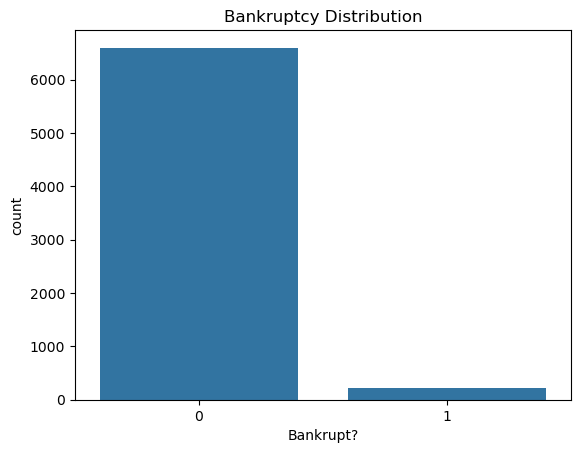

In [4]:
df['Bankrupt?'].value_counts()

# visualization
sns.countplot(x='Bankrupt?', data=df)
plt.title("Bankruptcy Distribution")
plt.show()

### Exploratory Data Analysis (EDA) ###

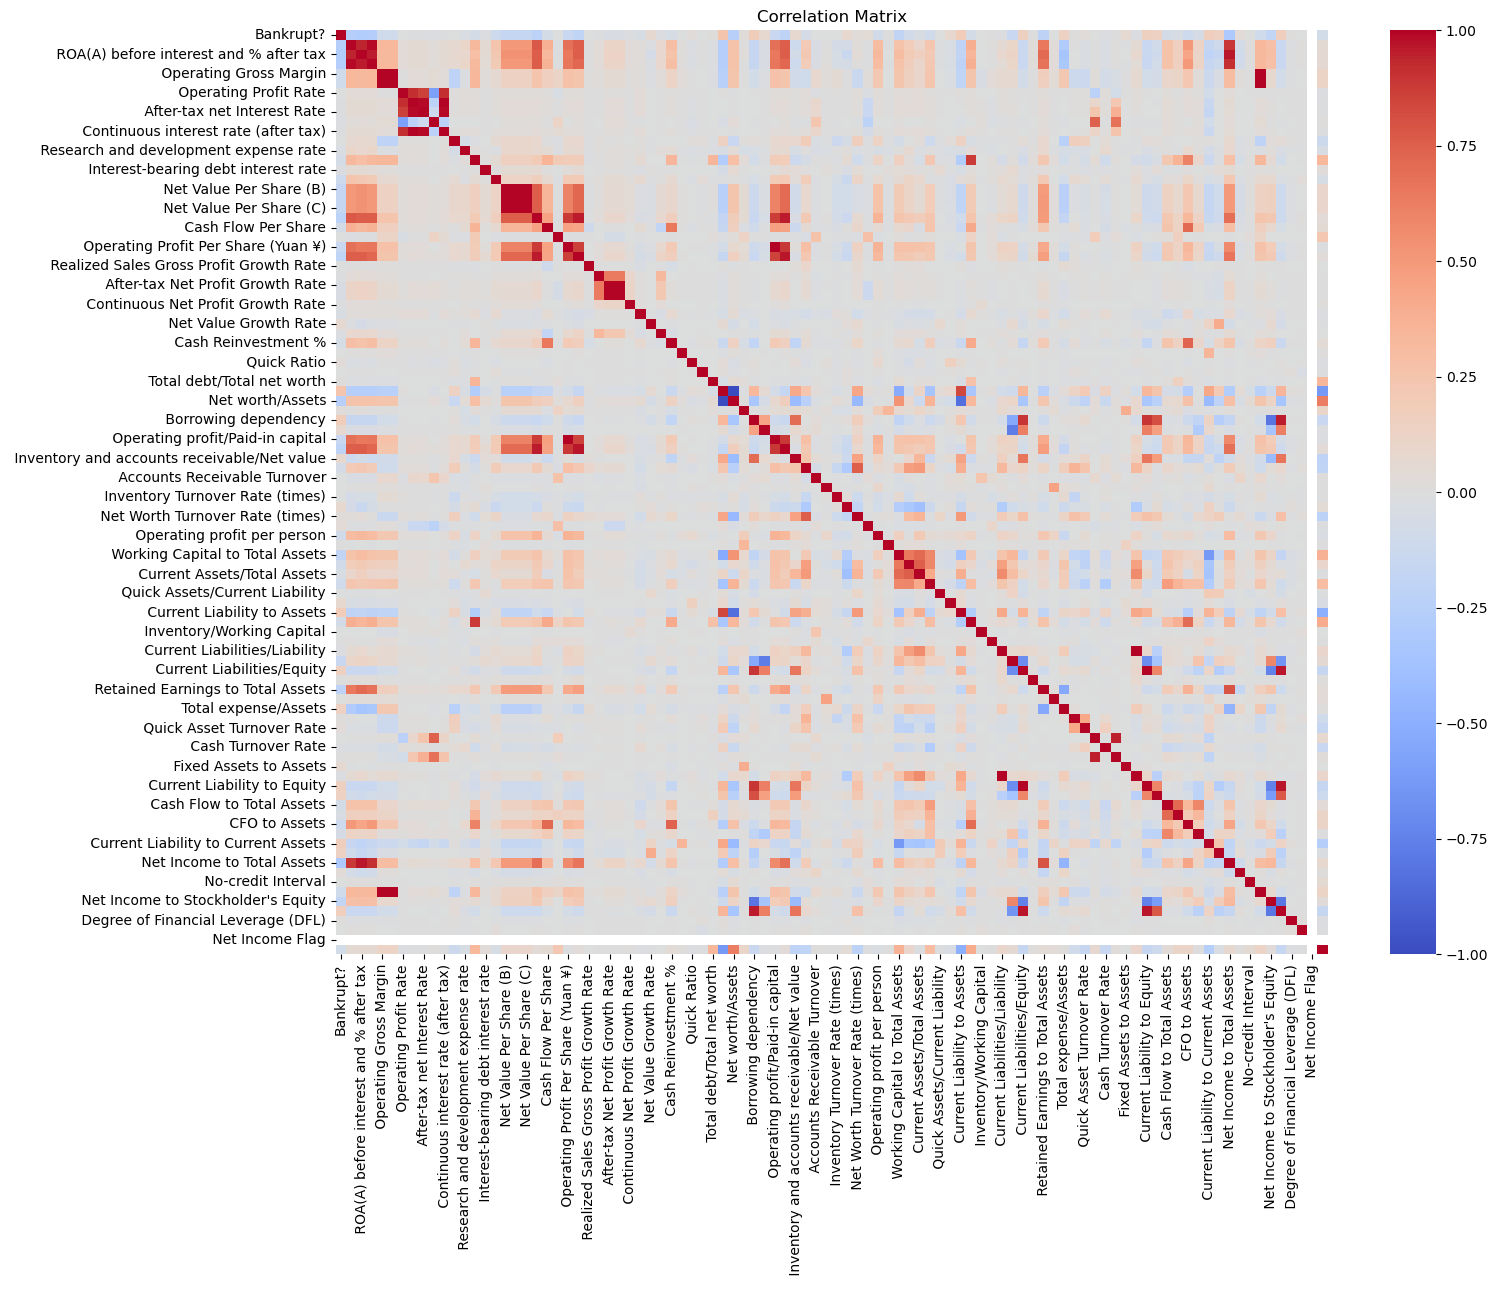

In [5]:
plt.figure(figsize=(16,12))

sns.heatmap(df.corr(),
            cmap='coolwarm',
            center=0)

plt.title("Correlation Matrix")
plt.show()


### Feature and Target Variable Selection ###


In [6]:
X = df.drop("Bankrupt?", axis=1)

y = df["Bankrupt?"]

### Splitting the Dataset into Training and Testing Sets ###

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Handling Class Imbalance Using Random Undersampling ###

In [8]:
rus = RandomUnderSampler(random_state=42)

X_train, y_train = rus.fit_resample(X_train, y_train)

print(y_train.value_counts())

Bankrupt?
0    176
1    176
Name: count, dtype: int64


### Feature Scaling and Data Standardization ###

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### Building Machine Learning Models ###

In [10]:
# Logistic Regression
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [11]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [12]:
# Random Forest 
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [13]:
# Supprot Vector Machine 
svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

### Model Evaluation Function ###

In [14]:
def evaluate_model(actual, predicted):

    print("Accuracy :", accuracy_score(actual, predicted))
    print("Precision:", precision_score(actual, predicted))
    print("Recall   :", recall_score(actual, predicted))
    print("F1 Score :", f1_score(actual, predicted))

    print("\nClassification Report\n")
    print(classification_report(actual, predicted))

In [15]:
print("Logistic Regression")
evaluate_model(y_test, lr_pred)

print("Decision Tree")
evaluate_model(y_test, dt_pred)

print("Random Forest")
evaluate_model(y_test, rf_pred)

print("Support Vector Machine")
evaluate_model(y_test, svm_pred)

Logistic Regression
Accuracy : 0.8467741935483871
Precision: 0.14893617021276595
Recall   : 0.7954545454545454
F1 Score : 0.25089605734767023

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.85      0.91      1320
           1       0.15      0.80      0.25        44

    accuracy                           0.85      1364
   macro avg       0.57      0.82      0.58      1364
weighted avg       0.96      0.85      0.89      1364

Decision Tree
Accuracy : 0.7925219941348973
Precision: 0.1157556270096463
Recall   : 0.8181818181818182
F1 Score : 0.2028169014084507

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.79      0.88      1320
           1       0.12      0.82      0.20        44

    accuracy                           0.79      1364
   macro avg       0.55      0.80      0.54      1364
weighted avg       0.96      0.79      0.86      1364

Random Forest
Accuracy

### Visualizing the Confusion Matrix ###

plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

### Building an Ensemble Voting Classifier ###

In [16]:
voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression()),
        ('dt', DecisionTreeClassifier()),
        ('rf', RandomForestClassifier())
    ],
    voting='hard'
)

voting.fit(X_train, y_train)

vote_pred = voting.predict(X_test)

In [17]:
evaluate_model(y_test, vote_pred)

Accuracy : 0.8695014662756598
Precision: 0.18095238095238095
Recall   : 0.8636363636363636
F1 Score : 0.2992125984251969

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.87      0.93      1320
           1       0.18      0.86      0.30        44

    accuracy                           0.87      1364
   macro avg       0.59      0.87      0.61      1364
weighted avg       0.97      0.87      0.91      1364



### Hyperparameter Tuning Using GridSearchCV ###

In [18]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


In [19]:
# Best Model
best_rf = grid.best_estimator_

pred = best_rf.predict(X_test)

evaluate_model(y_test, pred)

Accuracy : 0.874633431085044
Precision: 0.18090452261306533
Recall   : 0.8181818181818182
F1 Score : 0.2962962962962963

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1320
           1       0.18      0.82      0.30        44

    accuracy                           0.87      1364
   macro avg       0.59      0.85      0.61      1364
weighted avg       0.97      0.87      0.91      1364



### Analyzing Feature Importance ###

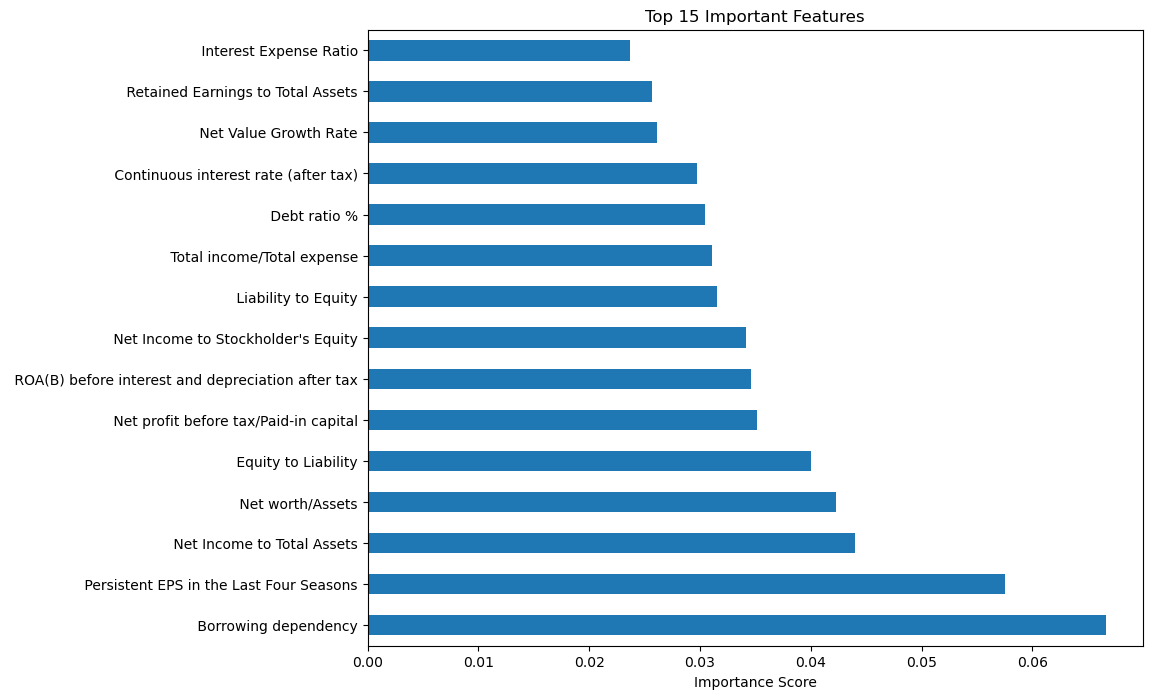

In [20]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,8))

importance.head(15).plot(kind='barh')

plt.title("Top 15 Important Features")

plt.xlabel("Importance Score")

plt.show()

### Save Model ###

In [21]:
import joblib

joblib.dump(best_rf, "Bankruptcy_Model.pkl")

joblib.dump(scaler, "Scaler.pkl")

['Scaler.pkl']